In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy import stats
import os
from stoch_sim_model import *
from optimize_nets import *
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [2]:
num_pnts = 10
runs = 10
sample_virs = np.array(np.meshgrid(d_S*np.linspace(10, 125, num_pnts), # vary d_I
                                   K_IE*np.logspace(0.0, 3, num_pnts), # vary K_IE
                                   b_I*np.linspace(0.5, 2.0, num_pnts), # vary b_I
                                   K_EH*np.array([1.0]), # vary K_EH
                                   N_0*np.array([1.0]), # vary N_0
                                       )).T.reshape(-1,5)

default_reg = act_psis + NE_psis + EM_psis + exp_psis

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"
# d="_local_data/"

In [3]:
# run simulations for extreme scenarios
run(batch = [-1], outdir=d, inf_sample = sample_virs, 
    comment="single-reg-vary-virs", runs = runs, vir_model = "indep_harm", default_reg = default_reg, 
    num_cpu = 90)

Running 10000 simulations in batch #-1
Saved sim_batch_-1-10-prim-single-reg-vary-virs.pkl
0.02592390603489346 hrs


In [4]:
d_file = d + '/sim_batch_-1-'+str(runs)+'-prim-single-reg-vary-virs.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

n = len(sample_virs)
parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]

In [5]:
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
sim_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).dropna(thresh=1)
use_data = sim_df.loc[sim_df['b_I']*sim_df['S_0'] >= sim_df['d_I']]

with pd.option_context('display.max_columns', None):
    display(use_data)

,S_0,I_0,b_I,d_S,d_I,d_IE,K_IE,b_H,d_H,K_EH,N_0,max_Na,b_myc,d_myc,myc_thresh,t_bind,t_unbind,t_Na_div,t_E_div,t_M_div,t_E_die,t_act,psi_Nact_I,psi_Nact_H,psi_Nact_P,F0_Nact,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_Ediv_I,psi_Ediv_H,psi_Ediv_P,F0_Ediv,p_load,T_max_pI,T_min_pI,harm_pI,harm_pS,max_pE,T_pE_max,T_pE_start,max_pM,T_pM_min,int_pP,int_pH,min_pS
0,10000000.0,1000.0,5.000000e-08,0.01,0.10,16.0,1.000000e+04,1.0,2.0,50000.0,300.0,4.0,4.0,2.0,1.0,0.75,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,0.0,0.0,3.0,3.0,0.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,0.0,0.0,3.597854e+04,6.35,7.63,1.887558e+04,1.717684e+04,7140.0,7.72,2.355433,537.0,2.134846,1.622728e+04,9.437792e+03,9.966798e+06
1,10000000.0,1000.0,5.000000e-08,0.01,0.10,16.0,2.154435e+04,1.0,2.0,50000.0,300.0,4.0,4.0,2.0,1.0,0.75,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,0.0,0.0,3.0,3.0,0.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,0.0,0.0,9.040590e+04,8.54,9.90,4.603344e+04,7.437974e+04,36104.0,10.59,4.161600,2133.0,3.809368,5.568628e+04,2.301672e+04,9.886592e+06
2,10000000.0,1000.0,5.000000e-08,0.01,0.10,16.0,4.641589e+04,1.0,2.0,50000.0,300.0,4.0,4.0,2.0,1.0,0.75,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,0.0,0.0,3.0,3.0,0.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,0.0,0.0,2.145117e+05,10.64,12.14,1.076265e+05,2.342734e+05,130789.0,12.85,5.650567,5751.0,4.259060,1.602212e+05,5.381326e+04,9.675344e+06
3,10000000.0,1000.0,5.000000e-08,0.01,0.10,16.0,1.000000e+05,1.0,2.0,50000.0,300.0,4.0,4.0,2.0,1.0,0.75,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,0.0,0.0,3.0,3.0,0.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,0.0,0.0,5.051246e+05,12.82,14.31,2.503512e+05,8.934757e+05,574029.0,15.23,9.242033,19764.0,5.461152,5.458533e+05,1.251754e+05,8.907986e+06
4,10000000.0,1000.0,5.000000e-08,0.01,0.10,16.0,2.154435e+05,1.0,2.0,50000.0,300.0,4.0,4.0,2.0,1.0,0.75,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,0.0,0.0,3.0,3.0,0.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,0.0,0.0,1.190221e+06,15.00,16.60,5.787360e+05,1.705542e+06,1265543.0,17.96,11.891733,32147.0,5.876314,1.035386e+06,2.893216e+05,7.793787e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,10000000.0,1000.0,2.000000e-07,0.01,1.25,16.0,4.641589e+05,1.0,2.0,50000.0,300.0,4.0,4.0,2.0,1.0,0.75,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,0.0,0.0,3.0,3.0,0.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,0.0,0.0,1.083499e+06,8.89,10.45,1.949709e+06,2.934621e+06,2752419.0,11.59,8.287533,57622.0,6.564731,1.764976e+06,9.748547e+05,5.354623e+06
9996,10000000.0,1000.0,2.000000e-07,0.01,1.25,16.0,1.000000e+06,1.0,2.0,50000.0,300.0,4.0,4.0,2.0,1.0,0.75,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,0.0,0.0,3.0,3.0,0.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,0.0,0.0,1.525586e+06,9.43,11.27,2.630913e+06,2.994742e+06,3170223.0,11.97,8.371833,46939.0,6.165996,1.859330e+06,1.315457e+06,4.656869e+06
9997,10000000.0,1000.0,2.000000e-07,0.01,1.25,16.0,2.154435e+06,1.0,2.0,50000.0,300.0,4.0,4.0,2.0,1.0,0.75,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,0.0,0.0,3.0,3.0,0.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,0.0,0.0,1.806615e+06,9.63,12.13,3.027093e+06,2.687079e+06,2908381.0,12.58,8.671667,37177.0,6.044582,1.727940e+06,1.513547e+06,4.588465e+06
9998,10000000.0,1000.0,2.000000e-07,0.01,1.25,16.0,4.641589e+06,1.0,2.0,50000.0,300.0,4.0,4.0,2.0,1.0,0.75,0.75,0.25,0.333333,0.5,2.5,0.25,3.0,3.0,0.0,0.0,3.0,3.0,0.0,4.0,-3.0,-3.0,0.0,-4.0,3.0,3.0,0.0,0.0,2.375041e+06,10.15,13.28,3.766563e+06,2.694743e+06,3318741.0,12.96,9.127833,30251.0,6.233251,1.746221e+06,1.883281e+06,3.891803e+06


### Understand noise structure of the simulations

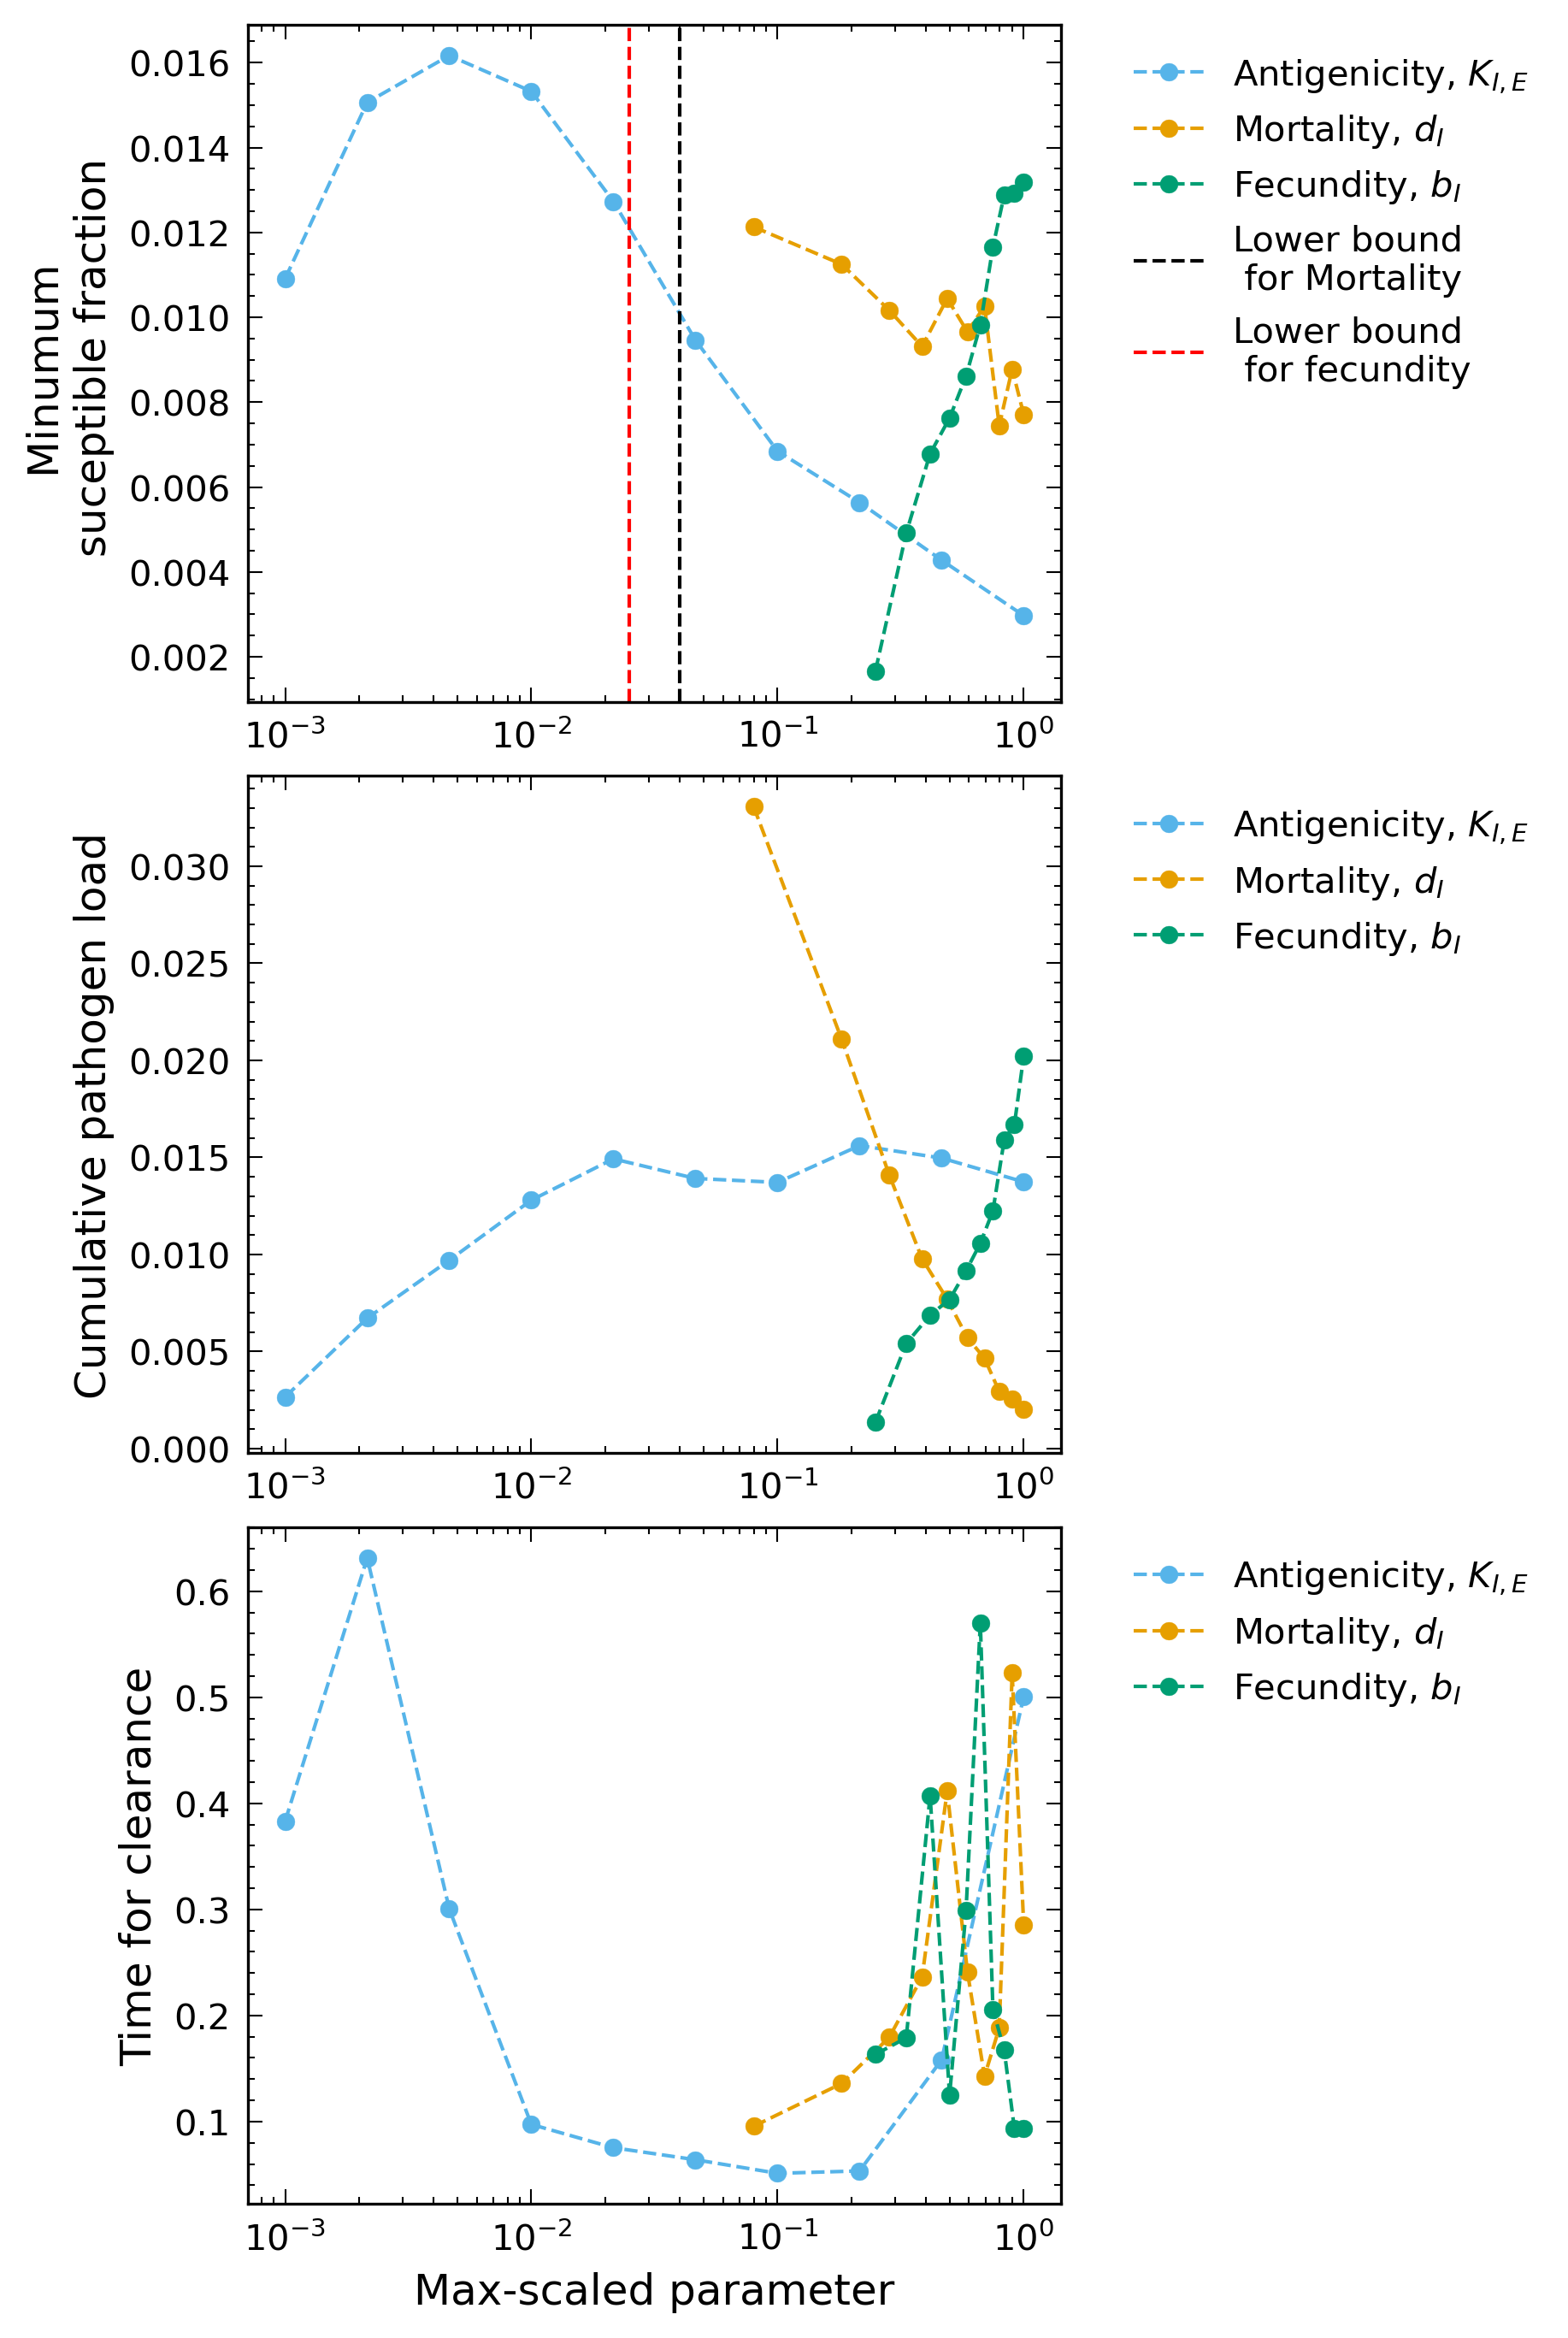

In [6]:
if runs > 1:
    # Plot simulated immune dynamics
    fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(6,9))
    
    ax1.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['K_IE'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax1.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Mortality, $d_{I}$')
    ax1.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
    ax1.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Mortality")
    ax1.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
    ax1.semilogx()
    ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    ax1.set(ylabel = 'Minumum \n suceptible fraction')
    
    ax2.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['K_IE'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax2.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Mortality, $d_{I}$')
    ax2.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
    ax2.semilogx()
    ax2.set(ylabel = 'Cumulative pathogen load')
    ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    
    ax3.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['K_IE'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax3.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Mortality, $d_{I}$')
    ax3.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_IE', 'd_I', 'b_I'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Fecundity, $b_{I}$')
    ax3.set(ylabel = 'Time for clearance', xlabel = 'Max-scaled parameter')
    ax3.semilogx()
    ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    
    
    plt.savefig('_figs/vir_parameter_lineplots', dpi=300, bbox_inches='tight')

### Understand Performance distrubution of the simulations

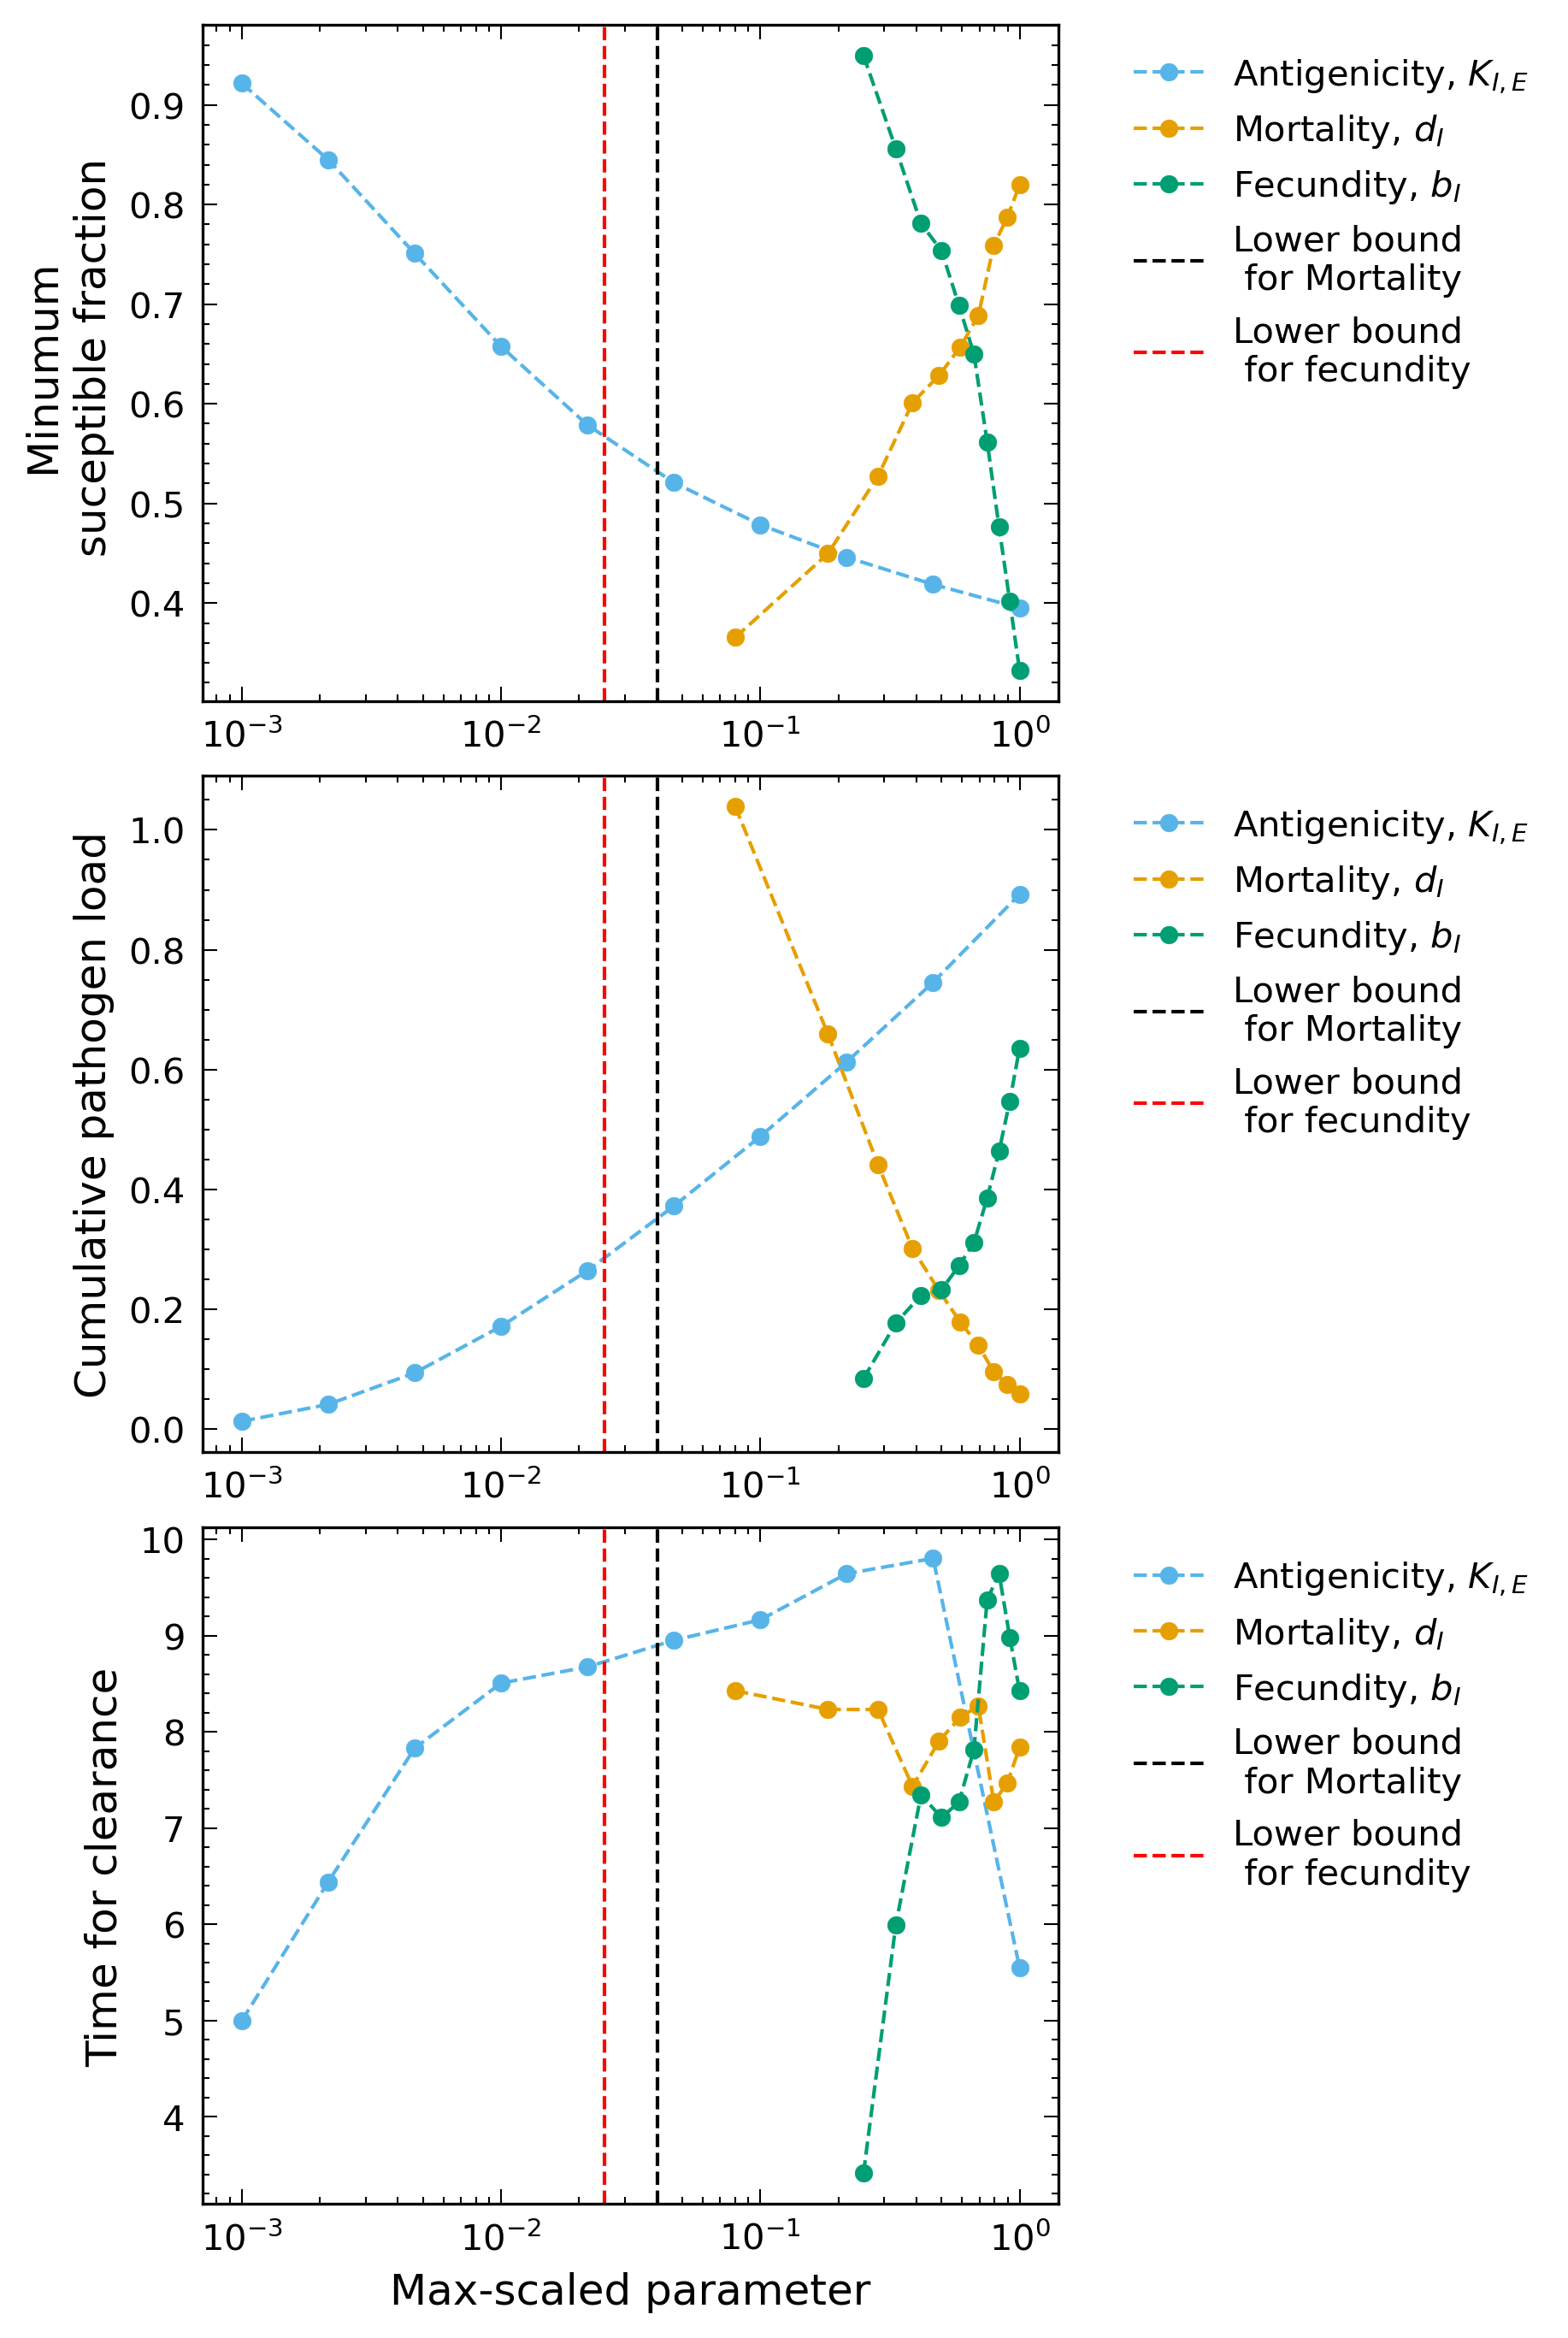

In [7]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(6,9))

ax1.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
ax1.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Mortality, $d_{I}$')
ax1.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
ax1.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Mortality")
ax1.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax1.semilogx()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
ax1.set(ylabel = 'Minumum \n suceptible fraction')

ax2.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
ax2.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Mortality, $d_{I}$')
ax2.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
ax2.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Mortality")
ax2.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax2.semilogx()
ax2.set(ylabel = 'Cumulative pathogen load')
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Antigenicity, $K_{I,E}$')
ax3.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Mortality, $d_{I}$')
ax3.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['T_min_pI'], 'o--', label = 'Fecundity, $b_{I}$')
ax3.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Mortality")
ax3.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax3.set(ylabel = 'Time for clearance', xlabel = 'Max-scaled parameter')
ax3.semilogx()
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')


plt.savefig('_figs/vir_parameter_lineplots', dpi=300, bbox_inches='tight')

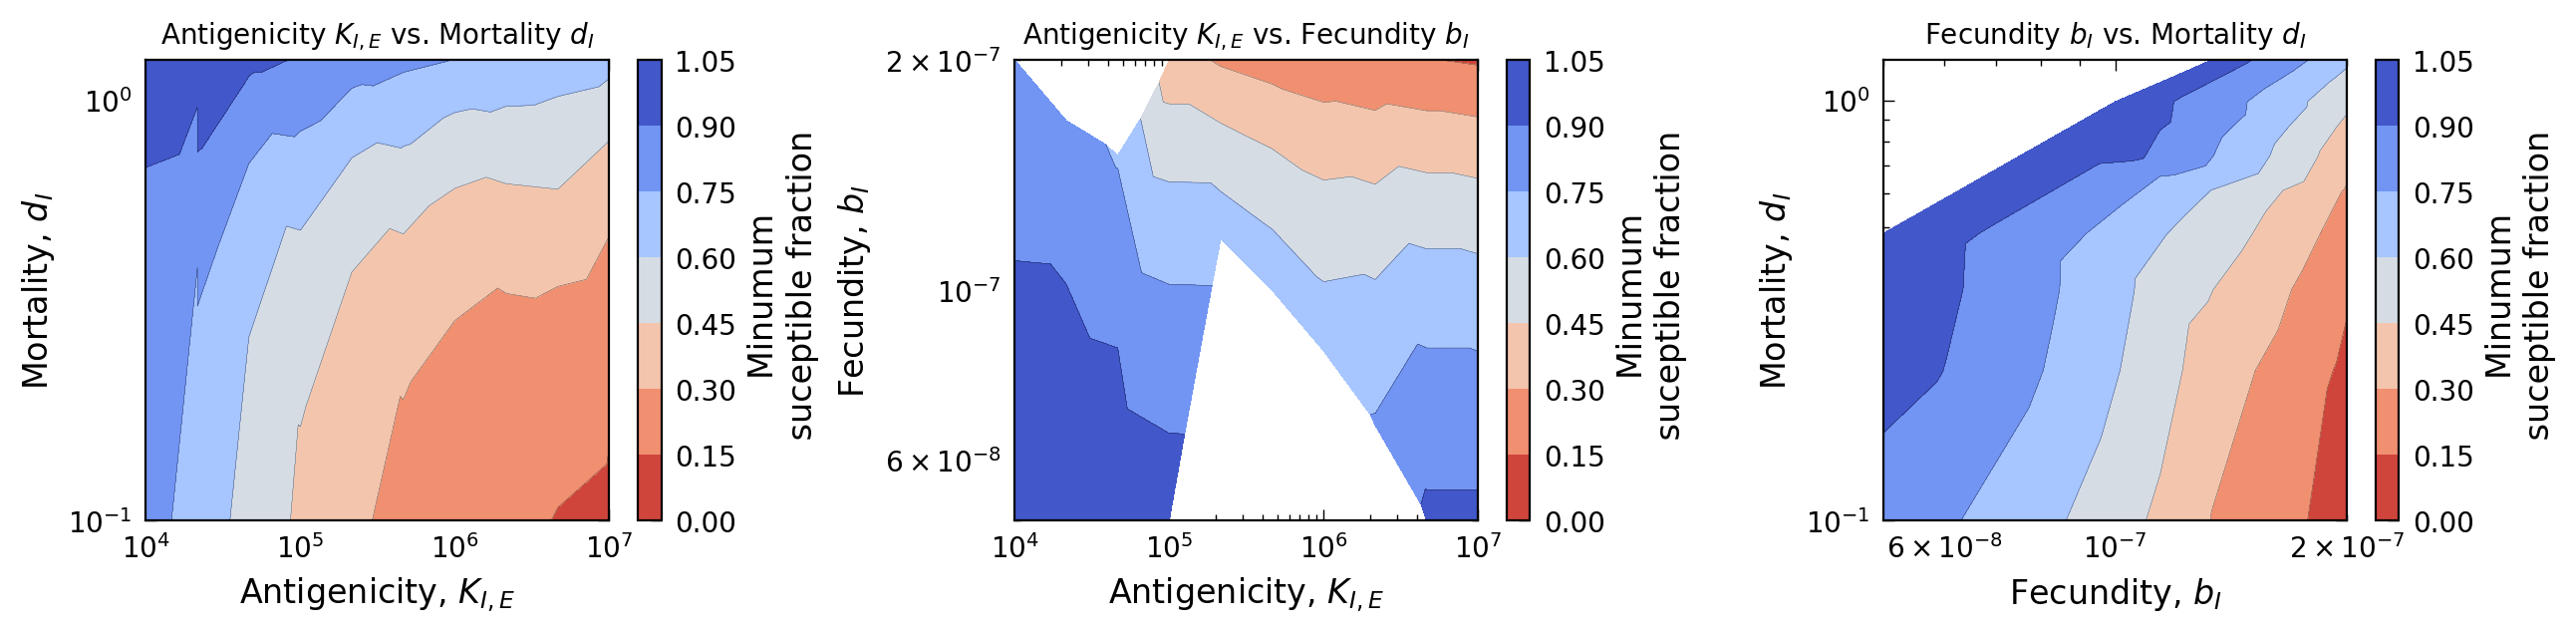

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

axs[0].tricontour(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                  use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                  use_data.groupby(['K_IE','d_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im0 = axs[0].tricontourf(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                        use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                        use_data.groupby(['K_IE','d_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r", norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[1].tricontour(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                  use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                  use_data.groupby(['K_IE','b_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im1 = axs[1].tricontourf(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                        use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                        use_data.groupby(['K_IE','b_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r", norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[2].tricontour(use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                  use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                  use_data.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im2 = axs[2].tricontourf(use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                        use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                        use_data.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r",norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Fecundity $b_I$ vs. Mortality $d_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[2].set_xlabel("Fecundity, $b_I$", fontsize = 12)

for j, ax in enumerate(axs.flat):
    ax.semilogy()
    ax.semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_contour', dpi=300, bbox_inches='tight')

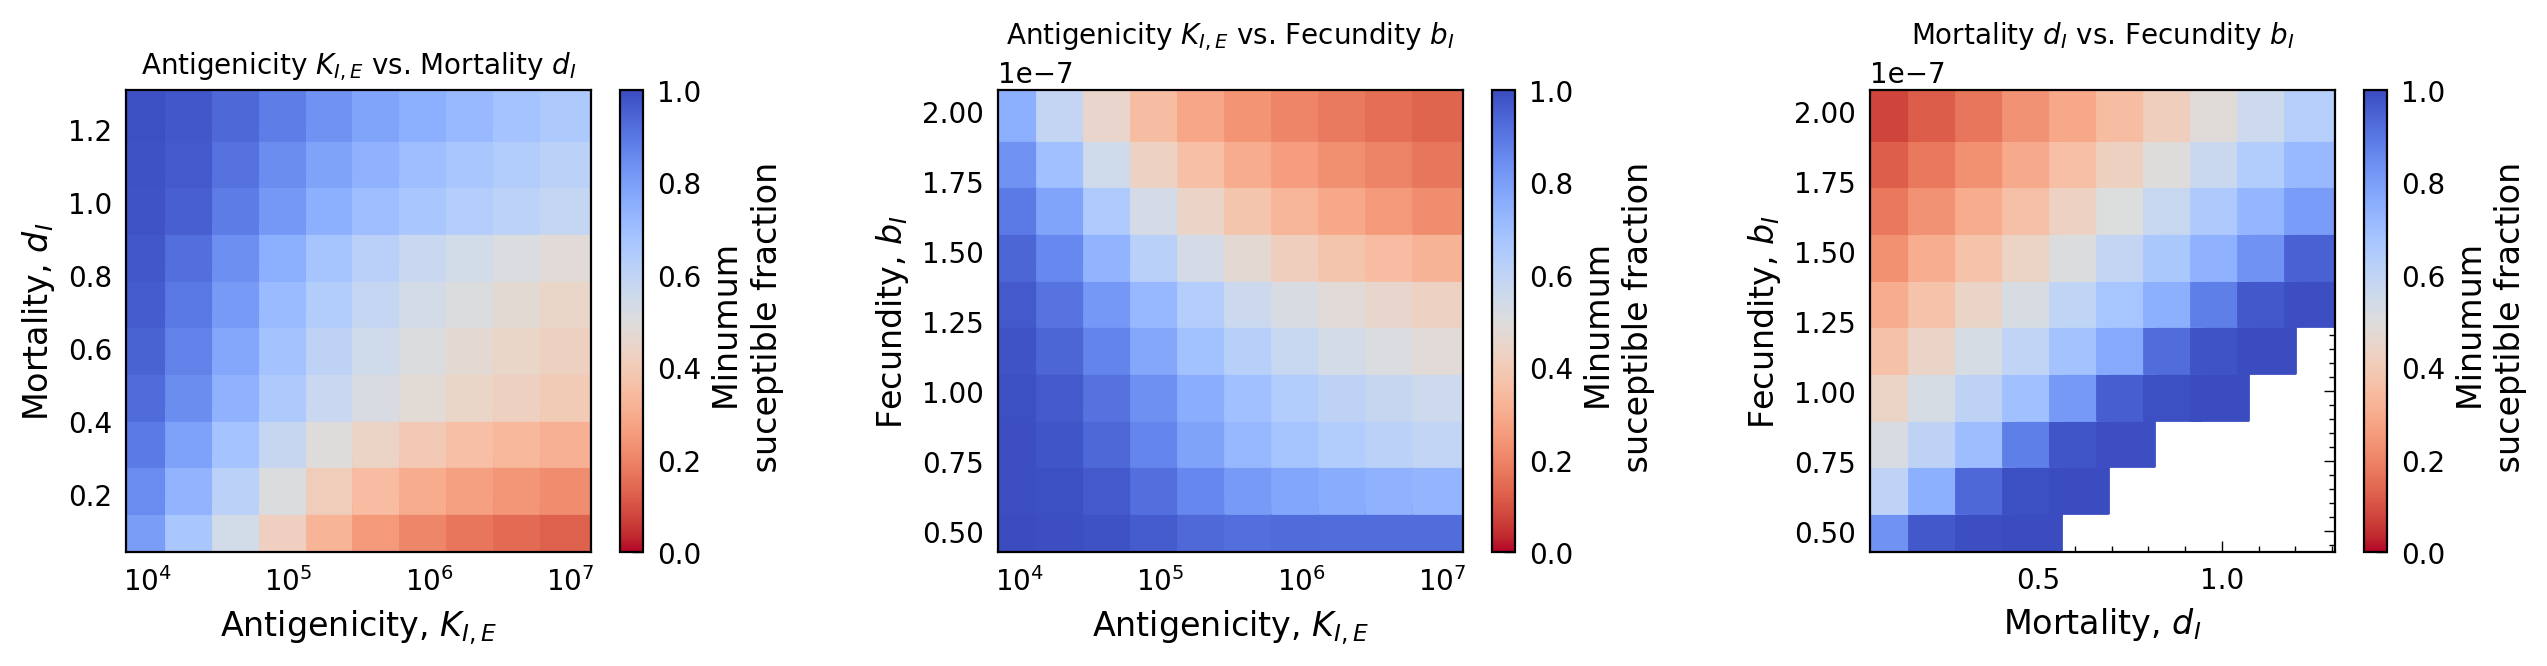

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

size = 4250/num_pnts

plot_data = use_data.groupby(['K_IE','d_I'], as_index=False).mean()
im0 = axs[0].scatter(plot_data['K_IE'], plot_data['d_I'], marker = 's', s = size,
                    c = plot_data['min_pS']/S_0, cmap='coolwarm_r', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
# axs[0].scatter(plot_data.loc[(plot_data['min_pS']/S_0 >= 0.485)*(plot_data['min_pS']/S_0 <= 0.515)]['K_IE'], plot_data.loc[(plot_data['min_pS']/S_0 >= 0.485)*(plot_data['min_pS']/S_0 <= 0.515)]['d_I'], marker = 'o', s = 5,
#                     color ='k')
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

plot_data = use_data.groupby(['K_IE','b_I'], as_index=False).mean()
im1 = axs[1].scatter(plot_data['K_IE'], plot_data['b_I'], marker = 's', s = size,
               c = plot_data['min_pS']/S_0, cmap='coolwarm_r', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

plot_data = use_data.groupby(['b_I','d_I'], as_index=False).mean()
im2 = axs[2].scatter(plot_data['d_I'], plot_data['b_I'], marker = 's', s = size,
               c = plot_data['min_pS']/S_0, cmap='coolwarm_r', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_heatmaps', dpi=300, bbox_inches='tight')

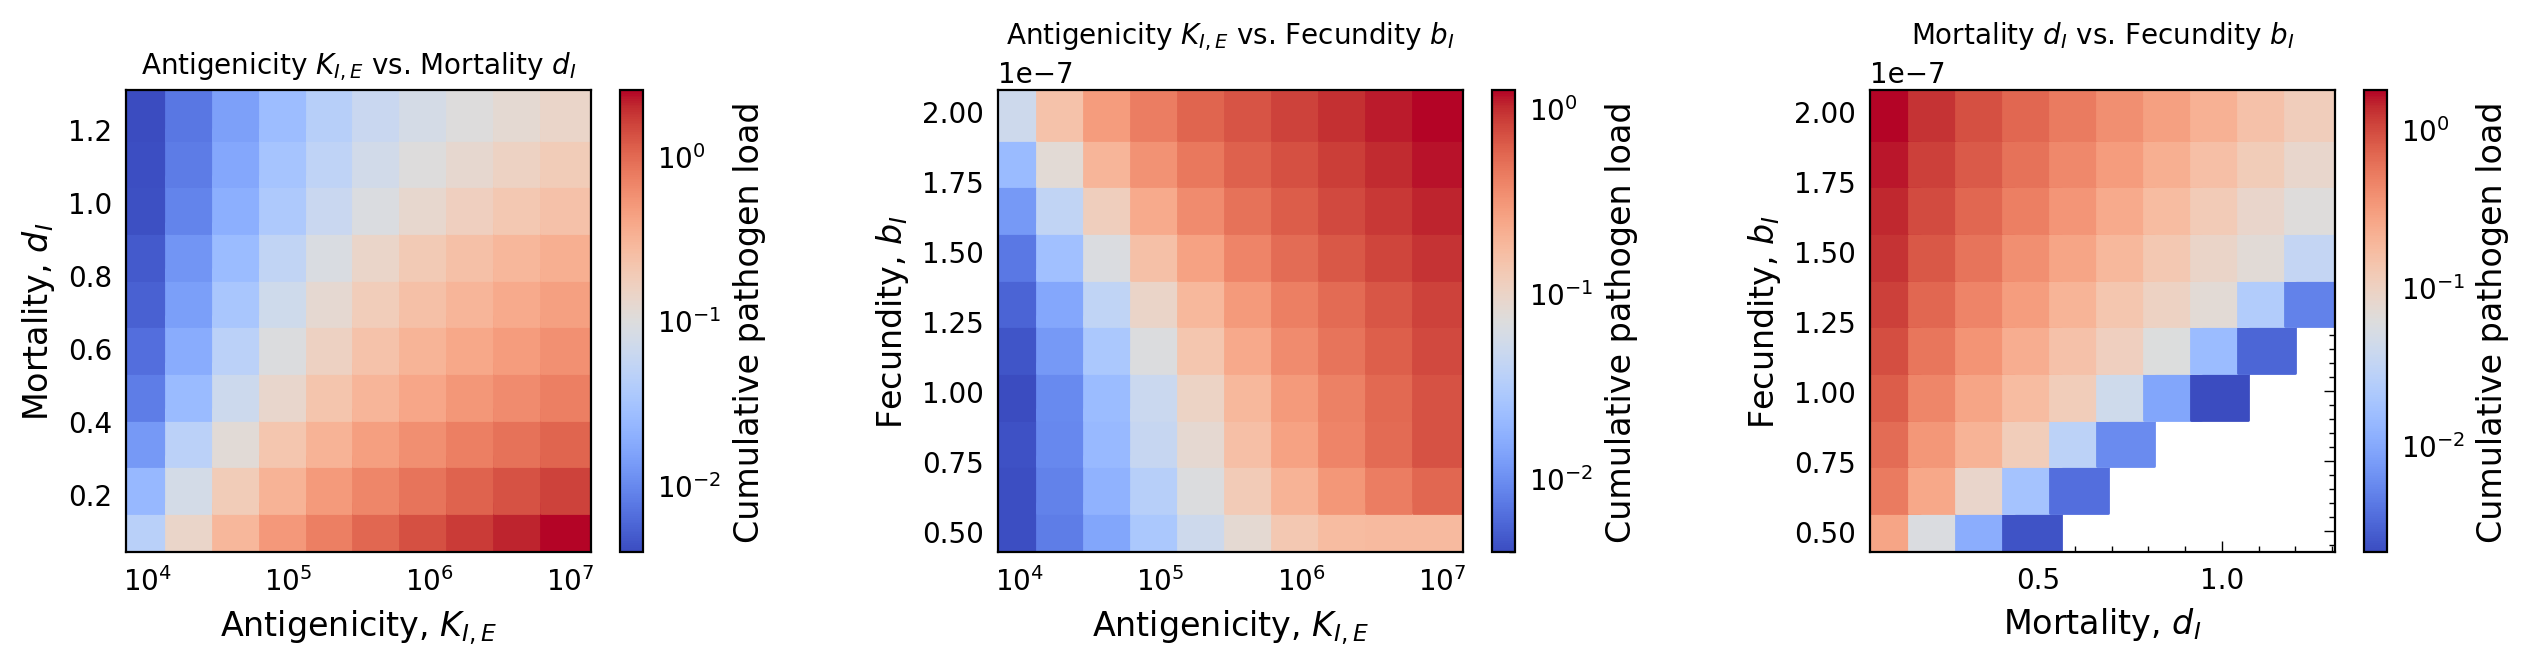

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['p_load']/S_0, cmap='coolwarm', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['p_load']/S_0, cmap='coolwarm', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['p_load']/S_0, cmap='coolwarm', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_pharm_heatmaps', dpi=300, bbox_inches='tight')

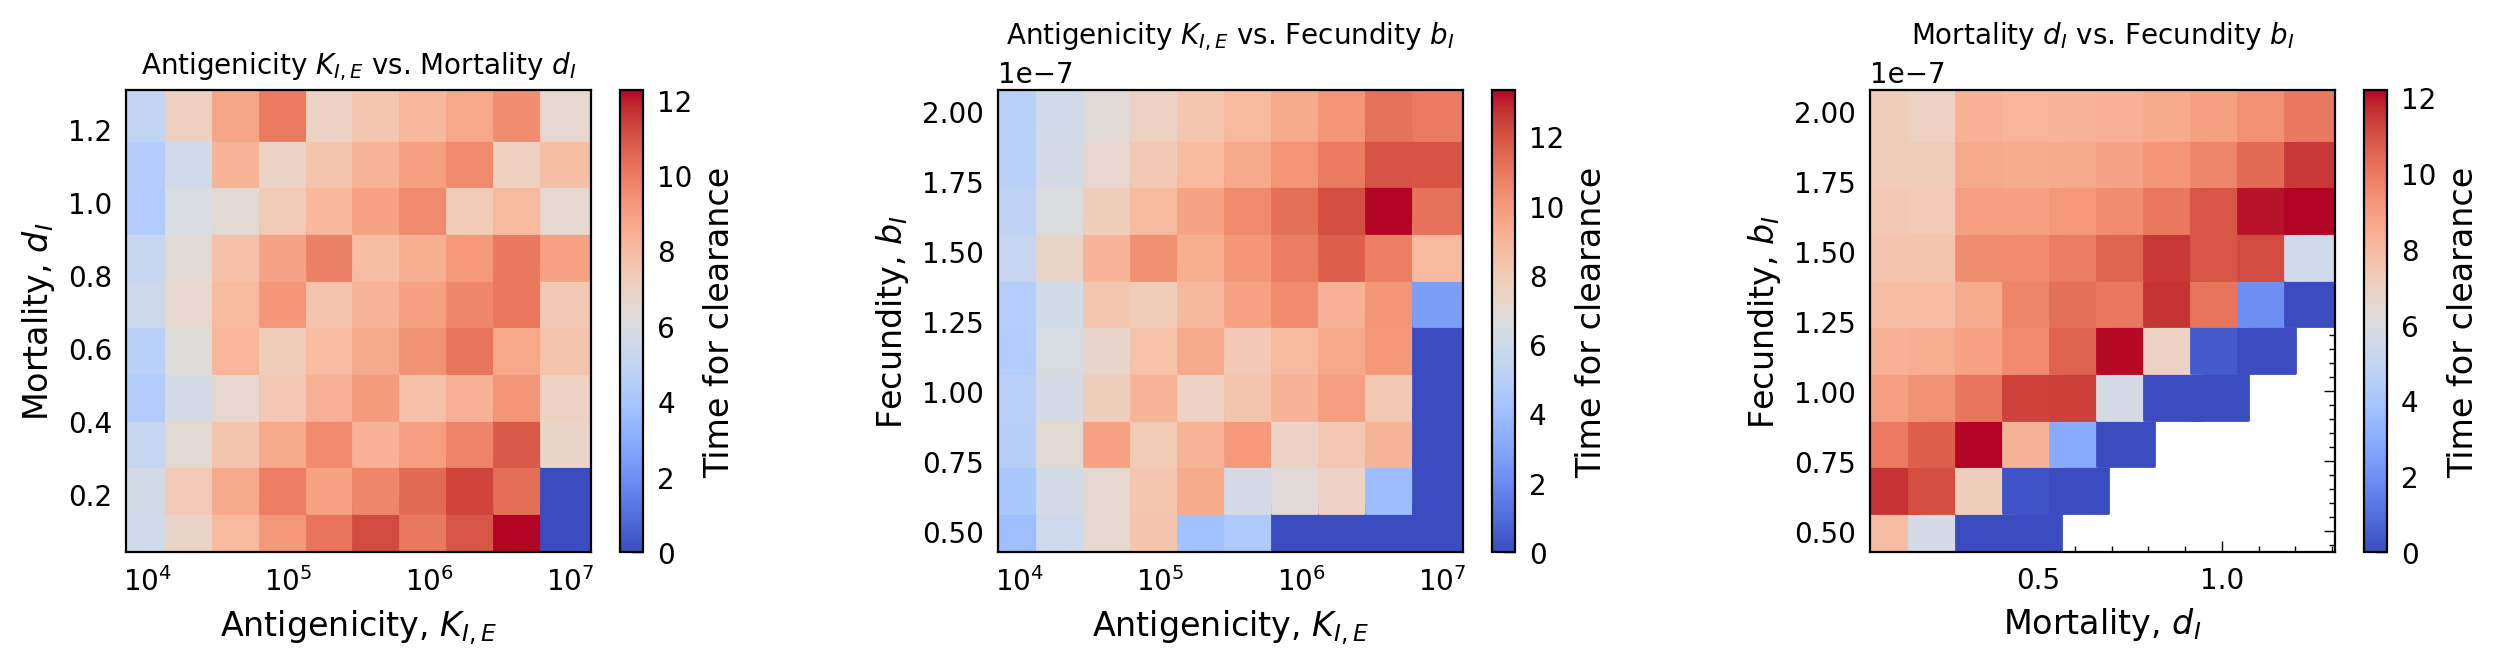

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['T_min_pI'], cmap='coolwarm')
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['T_min_pI'], cmap='coolwarm')
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['T_min_pI'], cmap='coolwarm')
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_ptiming_heatmaps', dpi=300, bbox_inches='tight')

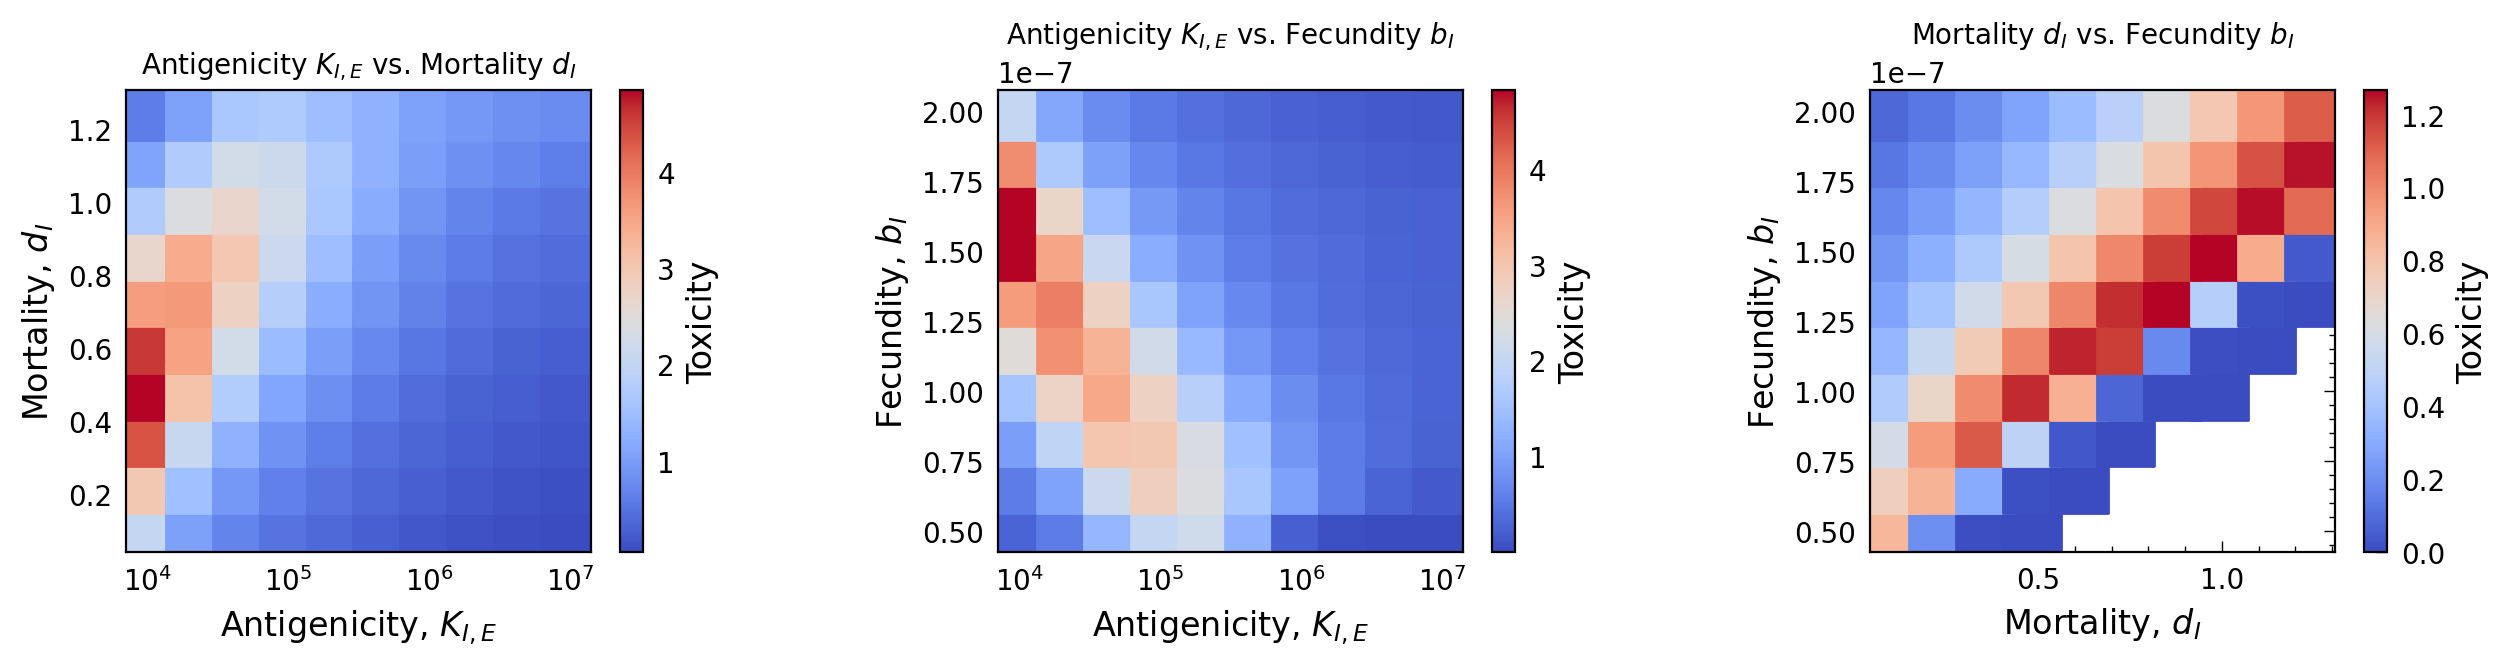

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['K_IE','d_I'], as_index=False).mean()['harm_pI'], cmap='coolwarm', norm=mpl.colors.Normalize())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['K_IE','b_I'], as_index=False).mean()['harm_pI'], cmap='coolwarm', norm=mpl.colors.Normalize())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['b_I','d_I'], as_index=False).mean()['harm_pI'], cmap='coolwarm', norm=mpl.colors.Normalize())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_toxicity_heatmaps', dpi=300, bbox_inches='tight')

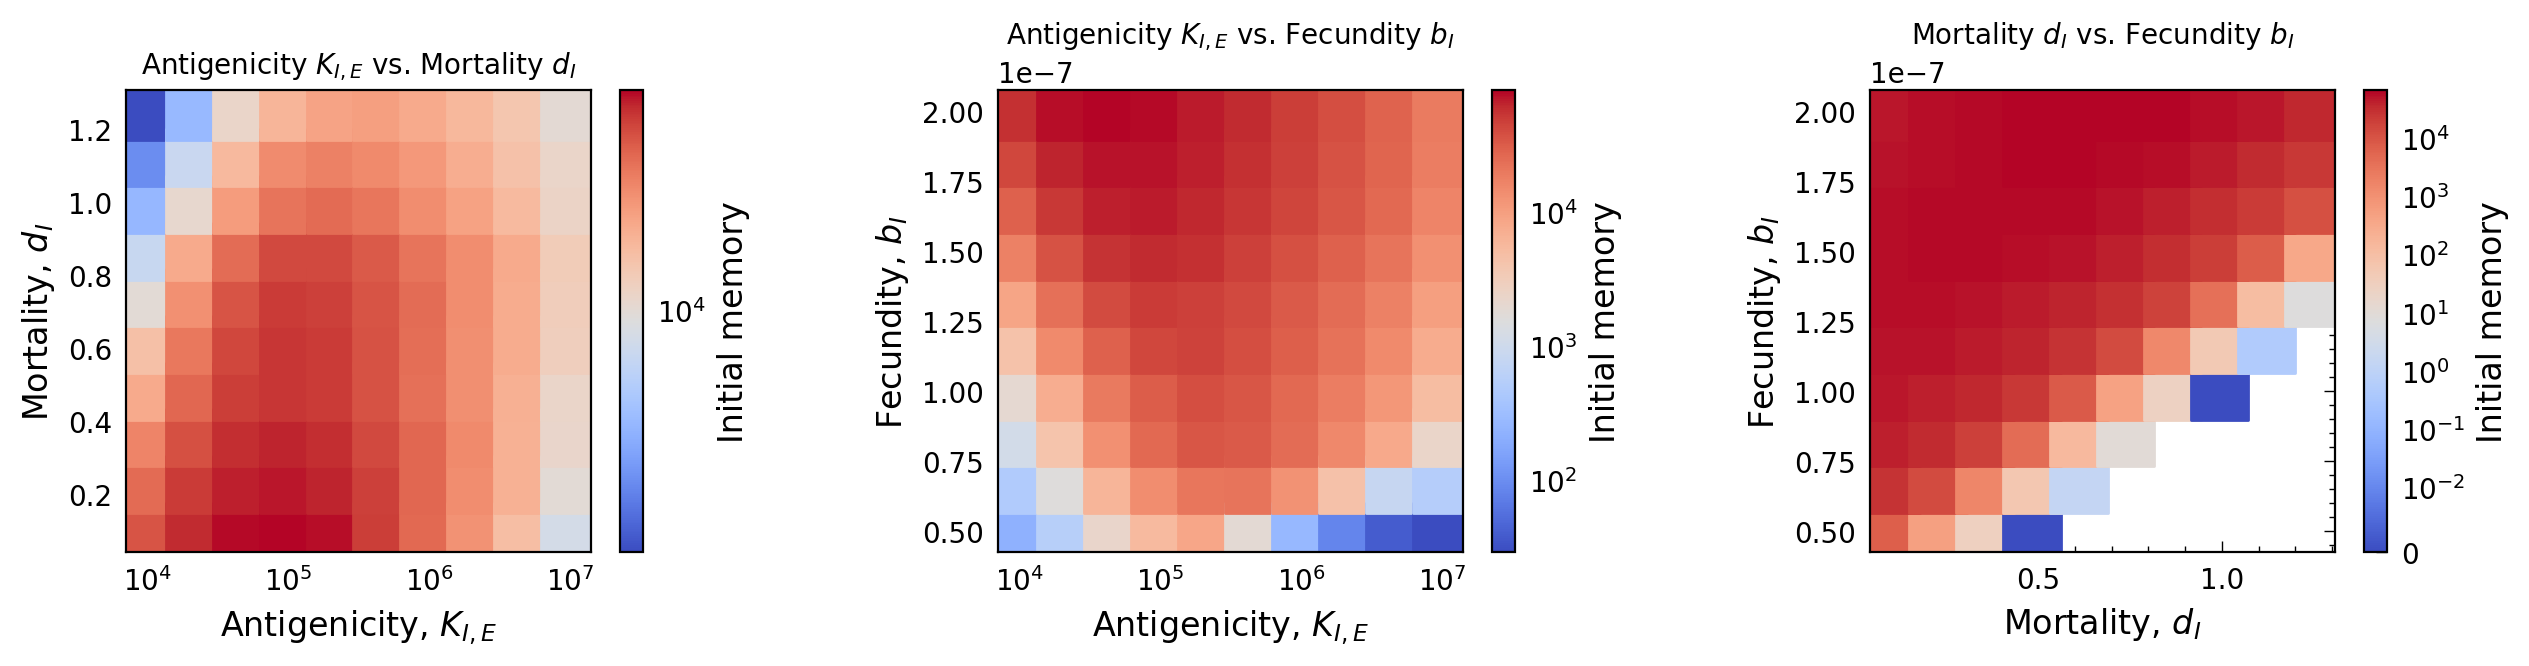

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['max_pM'], cmap='coolwarm', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['max_pM'], cmap='coolwarm', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['max_pM'], cmap='coolwarm', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_memory_heatmaps', dpi=300, bbox_inches='tight')

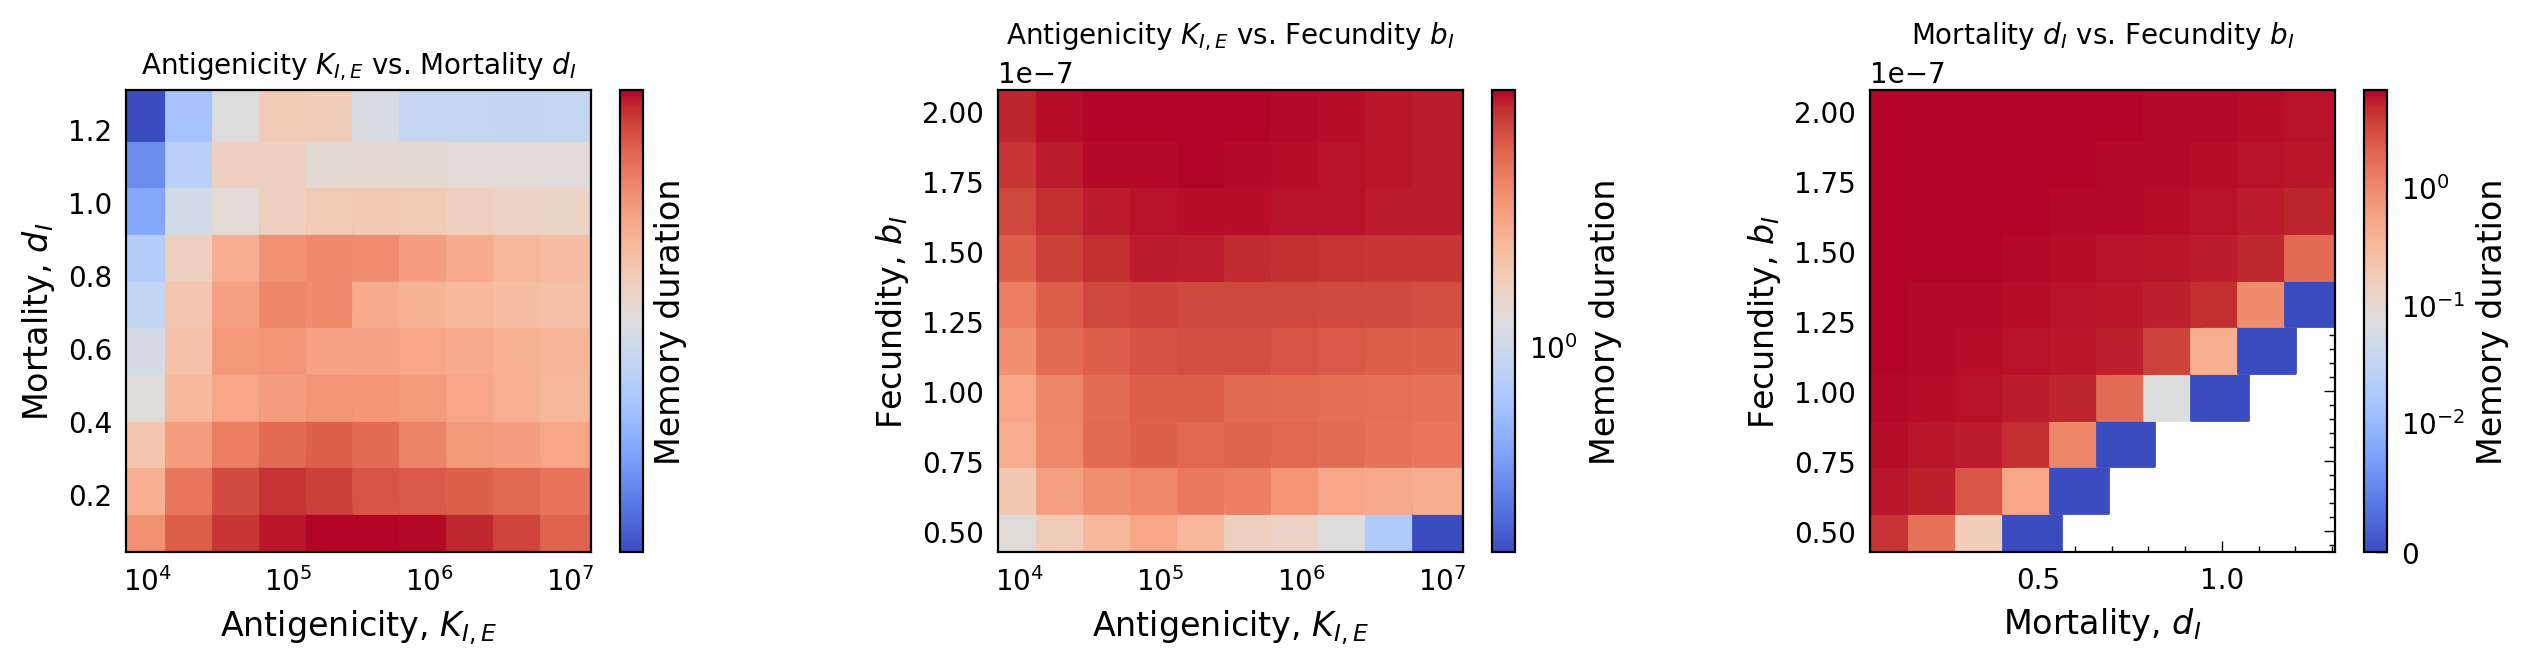

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['T_pM_min'], cmap='coolwarm', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Memory duration", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['T_pM_min'], cmap='coolwarm', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Memory duration", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['T_pM_min'], cmap='coolwarm', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Memory duration", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_memory_duration_heatmaps', dpi=300, bbox_inches='tight')